<a href="https://colab.research.google.com/github/latifahaljurayyan/insightApp/blob/main/GP2__2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd


In [31]:
url = "https://raw.githubusercontent.com/latifahaljurayyan/insightApp/refs/heads/main/google_play_appS_reviews.csv"
df = pd.read_csv(url)
print(df.shape)

(15000, 4)


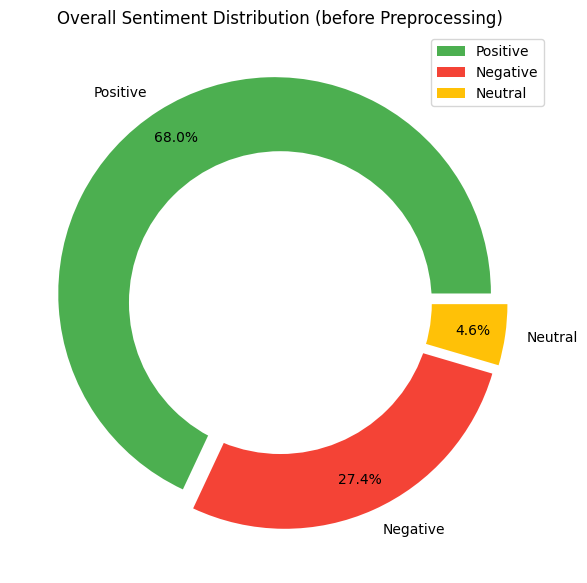

In [32]:
import matplotlib.pyplot as plt


sentiment_counts = df["sentiment_label"].value_counts()

sizes = sentiment_counts.values
labels = sentiment_counts.index

colors = ['#4CAF50', '#F44336', '#FFC107']

explode = [0.05] * len(labels)

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors[:len(labels)],
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Overall Sentiment Distribution (before Preprocessing)")

plt.legend(labels, loc="upper right")

plt.tight_layout()
plt.show()

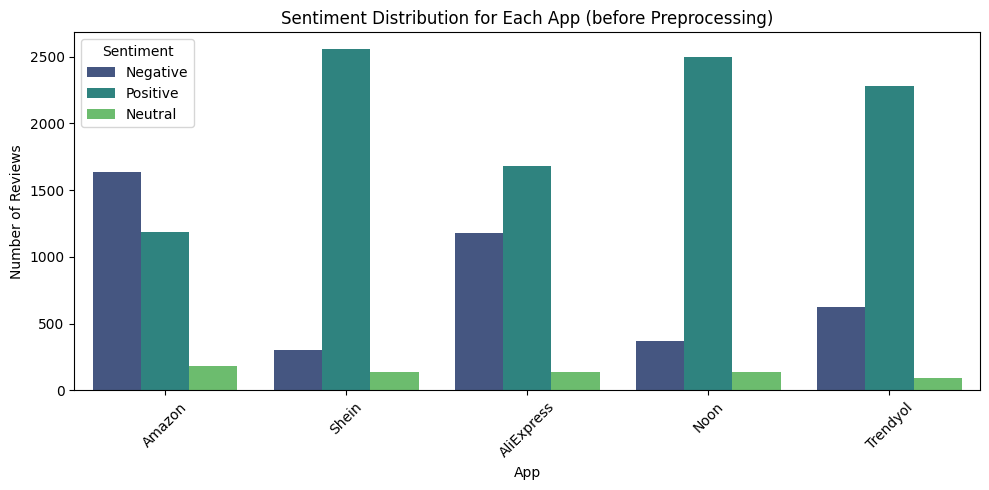

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

df_before = df.copy()
plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_before,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (before Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [34]:
print ("Before: \n", df_before["sentiment_label"]. value_counts ())

Before: 
 sentiment_label
Positive    10205
Negative     4111
Neutral       684
Name: count, dtype: int64


In [35]:
df = df[df["review_text"].astype(str).str.contains(r"[A-Za-z]", na=False)].copy()
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip().ne("")].copy()

print("After language/empty filtering:", len(df))

After language/empty filtering: 14426


In [36]:
import re



def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.lower()

    return text



df["clean_review"] = df["review_text"].apply(clean_text)

In [37]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,won't let me change my password and take off m...,wont let me change my password and take off my...
1,It doesn't load and glitches. I can't find any...,it doesnt load and glitches i cant find anythi...
2,"This used to be the best! Now, almost every sh...",this used to be the best now almost every ship...
3,THIS IS UNFAIR! I've literally ordered multipl...,this is unfair ive literally ordered multiple ...
4,way too hard to contact an agent for help. hor...,way too hard to contact an agent for help horr...
5,"Living in small town, I have access to little ...",living in small town i have access to little s...
6,Amazon is very fantastic and highly recommend,amazon is very fantastic and highly recommend
7,goes to login after switching phones. finds ou...,goes to login after switching phones finds out...
8,"Brilliant, I love shopping here .",brilliant i love shopping here
9,why Morocco isn't in the list of countries... ...,why morocco isnt in the list of countries even...


In [10]:
import nltk
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [11]:
df["Tokens"]= df["clean_review"].apply(word_tokenize)
df[[ "clean_review","Tokens"]].head(5)

,clean_review,Tokens
0,wont let me change my password and take off my...,"[wont, let, me, change, my, password, and, tak..."
1,it doesnt load and glitches i cant find anythi...,"[it, doesnt, load, and, glitches, i, cant, fin..."
2,this used to be the best now almost every ship...,"[this, used, to, be, the, best, now, almost, e..."
3,this is unfair ive literally ordered multiple ...,"[this, is, unfair, ive, literally, ordered, mu..."
4,way too hard to contact an agent for help horr...,"[way, too, hard, to, contact, an, agent, for, ..."


In [12]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["Tokens_No_Stopwords"] = df["Tokens"].apply(remove_stopwords)


def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["Tokens_No_Stopwords_Lemmatized"] = df["Tokens_No_Stopwords"].apply(lemmatize_tokens)


df[["Tokens", "Tokens_No_Stopwords", "Tokens_No_Stopwords_Lemmatized"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,Tokens,Tokens_No_Stopwords,Tokens_No_Stopwords_Lemmatized
0,"[wont, let, me, change, my, password, and, tak...","[wont, let, change, password, take, number, ad...","[wont, let, change, password, take, number, ad..."
1,"[it, doesnt, load, and, glitches, i, cant, fin...","[doesnt, load, glitches, cant, find, anything,...","[doesnt, load, glitch, cant, find, anything, s..."
2,"[this, used, to, be, the, best, now, almost, e...","[used, best, almost, every, shipment, gets, de...","[used, best, almost, every, shipment, get, del..."
3,"[this, is, unfair, ive, literally, ordered, mu...","[unfair, ive, literally, ordered, multiple, th...","[unfair, ive, literally, ordered, multiple, th..."
4,"[way, too, hard, to, contact, an, agent, for, ...","[way, hard, contact, agent, help, horrible, app]","[way, hard, contact, agent, help, horrible, app]"


In [13]:
df['tokens_str'] = df['Tokens_No_Stopwords_Lemmatized'].apply(lambda x: ' '.join(x))
df = df.drop_duplicates(subset='tokens_str', keep='first')

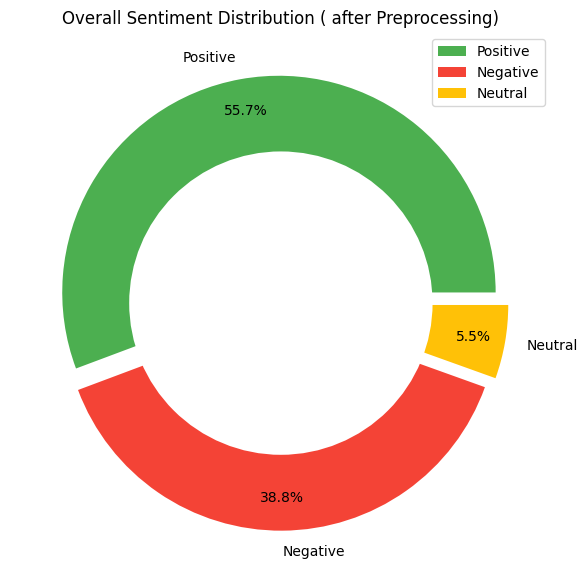

In [14]:

sentiment_counts = df["sentiment_label"].value_counts()

sizes = sentiment_counts.values
labels = sentiment_counts.index

colors = ['#4CAF50', '#F44336', '#FFC107']

explode = [0.05] * len(labels)

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors[:len(labels)],
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Overall Sentiment Distribution ( after Preprocessing)")

plt.legend(labels, loc="upper right")

plt.tight_layout()
plt.show()

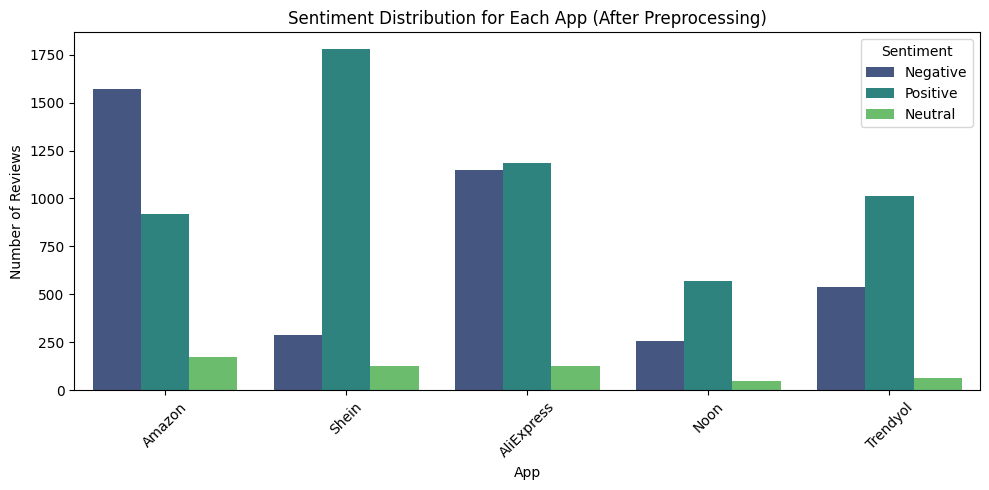

In [15]:
df_after = df.copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_after,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (After Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [16]:

print("\nAfter:\n", df_after["sentiment_label"].value_counts() )


After:
 sentiment_label
Positive    5463
Negative    3806
Neutral      538
Name: count, dtype: int64


In [17]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [18]:
from google.colab import files
files.download("google_play_app_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.0 MB/s eta 0:00:00


In [20]:
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from gensim.models import Word2Vec
import numpy as np


X_train_tokens = [text.split() for text in X_train_text]
X_test_tokens = [text.split() for text in X_test_text]

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    seed= 42
)

def get_sentence_vector(tokens, model, vector_size):
  vectors = [model.wv[word] for word in tokens if word in model.wv]

  if len(vectors) ==0:
    return np.zeros(vector_size)

  return np.mean(vectors, axis=0)

X_train = np.array([get_sentence_vector(tokens, w2v_model, 100)for tokens in X_train_tokens])
X_test = np.array([get_sentence_vector(tokens, w2v_model, 100) for tokens in X_test_tokens])

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Positive    4370
Negative    3045
Neutral      430
Name: count, dtype: int64
After SMOTE: sentiment_label
Neutral     4370
Positive    4370
Negative    4370
Name: count, dtype: int64


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.7599388379204893
Classification Report:
               precision    recall  f1-score   support

    Negative       0.72      0.78      0.75       761
     Neutral       0.09      0.09      0.09       108
    Positive       0.86      0.81      0.84      1093

    accuracy                           0.76      1962
   macro avg       0.56      0.56      0.56      1962
weighted avg       0.77      0.76      0.76      1962



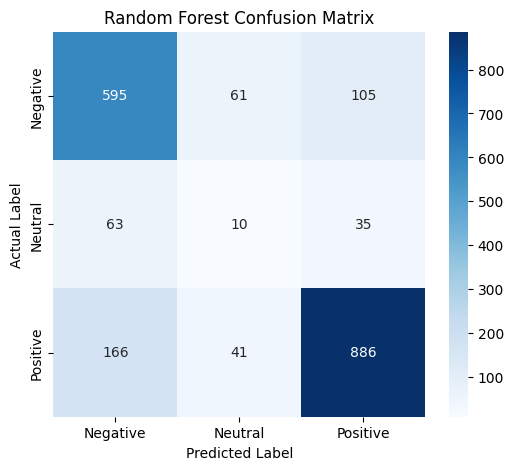

In [23]:

cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [24]:
from sklearn.tree import DecisionTreeClassifier




dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_resampled, y_train_resampled)


y_pred = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6681957186544343

Classification Report:

              precision    recall  f1-score   support

    Negative       0.67      0.65      0.66       761
     Neutral       0.06      0.13      0.08       108
    Positive       0.82      0.73      0.77      1093

    accuracy                           0.67      1962
   macro avg       0.52      0.51      0.51      1962
weighted avg       0.72      0.67      0.69      1962

Confusion Matrix:
 [[498 130 133]
 [ 56  14  38]
 [184 110 799]]


In [25]:

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_SVM = svm_model.predict(X_test)


print("SVM Accuracy:", accuracy_score(y_test, y_pred_SVM))
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))


SVM Accuracy: 0.6987767584097859

Classification Report:
               precision    recall  f1-score   support

    Negative       0.75      0.74      0.74       761
     Neutral       0.12      0.40      0.18       108
    Positive       0.91      0.70      0.79      1093

    accuracy                           0.70      1962
   macro avg       0.59      0.61      0.57      1962
weighted avg       0.80      0.70      0.74      1962



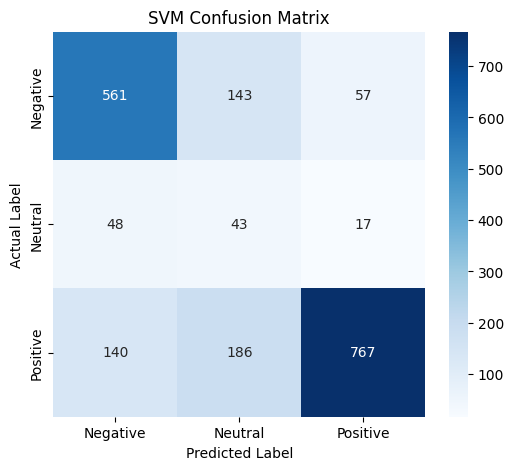

In [26]:
cm_svm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

Naive Bayes Accuracy: 0.6330275229357798

Classification Report:
               precision    recall  f1-score   support

    Negative       0.68      0.75      0.71       761
     Neutral       0.07      0.23      0.10       108
    Positive       0.86      0.59      0.70      1093

    accuracy                           0.63      1962
   macro avg       0.54      0.52      0.51      1962
weighted avg       0.75      0.63      0.67      1962



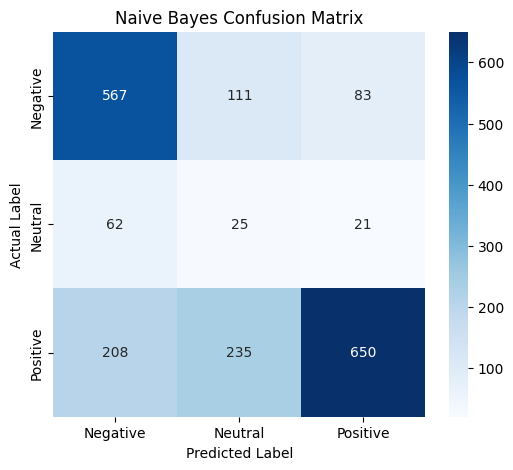

In [27]:
from sklearn.naive_bayes import GaussianNB


nb_model = GaussianNB()


nb_model.fit(X_train_resampled, y_train_resampled)


y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
# Confusion Matrix Graph

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Naive Bayes Confusion Matrix")
plt.show()


In [28]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:42:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8007135575942915

Classification Report:

              precision    recall  f1-score   support

    Negative       0.74      0.84      0.79       761
     Neutral       0.25      0.01      0.02       108
    Positive       0.85      0.85      0.85      1093

    accuracy                           0.80      1962
   macro avg       0.61      0.57      0.55      1962
weighted avg       0.77      0.80      0.78      1962

Confusion Matrix:

[[638   2 121]
 [ 63   1  44]
 [160   1 932]]


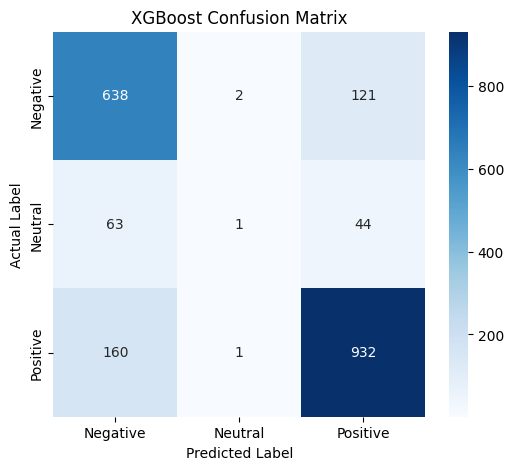

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBoost Confusion Matrix")
plt.show()